# Experimento: IntenCite - SciBERT Fine-tuning v2
Este notebook refina el experimento de clasificación de intención de citas (MultiCite) utilizando **SciBERT**, elevando el rigor técnico con:
1. **Pydantic** para configuración unificada y tipada.
2. **HuggingFace Datasets & DataCollator** para procesamiento y padding dinámico eficiente.
3. **PyTorch nn.Module** personalizado (`IntenCiteSciBERT`) sobre `AutoModel` para un control fino de la arquitectura.


In [ ]:
# try:
#   import google.colab
#   IN_COLAB = True
# except:
#   IN_COLAB = False

# if IN_COLAB:
#   !pip install -q transformers datasets peft mlflow pydantic scikit-learn
#   !pip install -q --upgrade torch torchvision
# else:
#   print("Entorno local. Se omiten instalaciones")

In [ ]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

if IN_COLAB:
  # 1. Instalar dependencias necesarias para el proyecto
  !pip install -q transformers datasets peft mlflow pydantic scikit-learn

  # 2. Eliminar las librerías problemáticas que chocan con HuggingFace
  !pip uninstall -y torchvision torchaudio

  print("Configuración lista")
  print("IMPORTANTE: Ve al menú superior 'Entorno de ejecución' (Runtime) -> 'Reiniciar sesión' (Restart session) ahora mismo antes de continuar con la siguiente celda.")
else:
  print("Entorno local. Se omiten instalaciones.")


Found existing installation: torchvision 0.29.0
Uninstalling torchvision-0.29.0:
  Successfully uninstalled torchvision-0.29.0
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128

✅ ¡Configuración lista!
⚠️ MUY IMPORTANTE: Ve al menú superior 'Entorno de ejecución' (Runtime) -> 'Reiniciar sesión' (Restart session) ahora mismo antes de continuar con la siguiente celda.


In [ ]:
import io
import json
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import torch
import torch.nn as nn

from IPython.display import display
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from pydantic import BaseModel
from typing import List, Dict, Optional
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding
from torch.optim import AdamW

from mlflow.models.signature import ModelSignature
from mlflow.types.schema import Schema, TensorSpec

from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, confusion_matrix
)

# Eliminada la importacion local para compatibilidad con Colab
# from intencite.config import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT

# Dispositivo
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using: {device}")


Using: cuda


## 1. Configuración del Experimento (Pydantic)
En lugar de constantes dispersas, definimos esquemas de validación de configuración. Esto con el fin de centralizar hiperparámetros, nombres de columnas y parámetros del modelo en un solo objeto tipado y seguro.


In [2]:
# TRACKING_URI = None
TRACKING_URI = "http://98.80.92.131:8080/"

In [3]:
IN_COLAB = True

In [ ]:
class DataConfig(BaseModel):
    if IN_COLAB:
        data_path: str = "./multicite_3ctx_balanceado.csv"
    else:
        data_path: str = "../../data/multicite_3ctx_balanceado.csv"
    text_col: str = "context"
    label_col: str = "label_proyecto"
    split_col: str = "split_proyecto"
    # Etiquetas reales -> IDs (Para la red neuronal)
    label2id: Dict[str, int] = {
        # "Gap": 0, "Comparison": 1, "Application": 2, "Background": 3, "Improvement": 4
        "Application": 0, "Background": 1, "Comparison": 2, "Gap": 3, "Improvement": 4
    }

class ModelConfig(BaseModel):
    model_name: str = "allenai/scibert_scivocab_uncased"
    num_classes: int = 5
    dropout_prob: float = 0.1
    special_tokens: List[str] = ["<cite>", "</cite>"]

class TrainingConfig(BaseModel):
    batch_size: int = 32 # 16
    learning_rate: float = 2e-5
    epochs: int = 50 # 6 # 3
    seed: int = 123

class MLflowConfig(BaseModel):
    # Flag para saber si estamos en Colab
    is_colab: bool = True
    # Reemplaza con la IP de EC2
    tracking_uri: Optional[str] = TRACKING_URI
    experiment_name: str = "intencite-model-comparison"

class ExperimentConfig(BaseModel):
    data: DataConfig = DataConfig()
    model: ModelConfig = ModelConfig()
    training: TrainingConfig = TrainingConfig()
    mlflow: MLflowConfig = MLflowConfig()

config = ExperimentConfig()

# Fijar semilla para reproducibilidad
torch.manual_seed(config.training.seed)
np.random.seed(config.training.seed)


In [5]:
print(config.model_dump_json(indent=2))

{
  "data": {
    "data_path": "./multicite_3ctx_balanceado.csv",
    "text_col": "context",
    "label_col": "label_proyecto",
    "split_col": "split_proyecto",
    "label2id": {
      "Application": 0,
      "Background": 1,
      "Comparison": 2,
      "Gap": 3,
      "Improvement": 4
    }
  },
  "model": {
    "model_name": "allenai/scibert_scivocab_uncased",
    "num_classes": 5,
    "dropout_prob": 0.1,
    "special_tokens": [
      "<cite>",
      "</cite>"
    ]
  },
  "training": {
    "batch_size": 32,
    "learning_rate": 0.00002,
    "epochs": 50,
    "seed": 123
  },
  "mlflow": {
    "is_colab": true,
    "tracking_uri": "http://98.80.92.131:8080/",
    "experiment_name": "intencite-model-comparison"
  }
}


## 2. Preparación de Datos (HF Datasets)
Cargamos los datos y los transformamos a objetos `Dataset` nativos de HuggingFace. Además, mapeamos las etiquetas de texto a índices numéricos.


In [6]:
# 1. Cargar el DataFrame
df = pd.read_csv(config.data.data_path)

# 2. Convertir Etiquetas a IDs numéricos
df['label_id'] = df[config.data.label_col].map(config.data.label2id)

# 3. Separar los splits
train_df = df[df[config.data.split_col] == "train"].copy()
val_df = df[df[config.data.split_col] == "val"].copy()
test_df = df[df[config.data.split_col] == "test"].copy()

# 4. Crear DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[[config.data.text_col, 'label_id']],
        preserve_index=False
        ),
    "val": Dataset.from_pandas(
        val_df[[config.data.text_col, 'label_id']],
        preserve_index=False
        ),
    "test": Dataset.from_pandas(
        test_df[[config.data.text_col, 'label_id']],
        preserve_index=False
        ),
})

# Renombrar columnas para estandarizar con HuggingFace (espera una columna 'labels')
dataset = dataset.rename_column("label_id", "labels")
dataset


DatasetDict({
    train: Dataset({
        features: ['context', 'labels'],
        num_rows: 2491
    })
    val: Dataset({
        features: ['context', 'labels'],
        num_rows: 483
    })
    test: Dataset({
        features: ['context', 'labels'],
        num_rows: 517
    })
})

## 3. Tokenización y Special Tokens
`SciBERT` no conoce el significado del tag delimitador de la cita en nuestro dataset: `<cite>`. Si se tokeniza directamente lo dividirá en piezas (probado experimentalmente).

Se agregará `<cite>` y `</cite>` como *Special Tokens* para que tengan un único ID y un `embedding` dedicado que la red deberá aprender a usar (i.e. ajustarlo).

In [7]:
# Cargar Tokenizador
tokenizer = AutoTokenizer.from_pretrained(config.model.model_name)

# Añadir Special Tokens (tags estructurales de la cita)
special_tokens_dict = {'additional_special_tokens': config.model.special_tokens}
num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)

print(f"{num_added_toks} Special tokens were added.")

# Función de tokenización
# NO usa padding, dado que se delega al DataCollator en tiempo real
context_col = config.data.text_col
def tokenize_function(examples):
    return tokenizer(
        examples[context_col],
        truncation=True,
        max_length=512
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets

2 Special tokens were added.


Map:   0%|          | 0/2491 [00:00<?, ? examples/s]

Map:   0%|          | 0/483 [00:00<?, ? examples/s]

Map:   0%|          | 0/517 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['context', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2491
    })
    val: Dataset({
        features: ['context', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 483
    })
    test: Dataset({
        features: ['context', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 517
    })
})

In [8]:
# Se elimina la columna de texto para usar sol tensores para PyTorch
tokenized_datasets = tokenized_datasets.remove_columns([config.data.text_col])
tokenized_datasets.set_format("torch")
tokenized_datasets["train"][0]


{'labels': tensor(3),
 'input_ids': tensor([  102,   111,   755,  1060,  4949,   121,  6487,  4367, 14807,  1995,
           487,  5901,  4588, 30121,  2190,   422,  2825,   235,   111,   615,
           131,  2327,  9340,  6309,   422,   165,   453,   205,   755,  1061,
          1078,  5896,   147,  2743, 17444, 30107,  9340,  6309,  8520,   191,
          2208,   453,  6035,   190,  2646,   147,   111,  1196, 16443,   131,
           111,  3117,   422,   259,   205,   139,   205,   422,  4371,  1352,
          1824,  8790,   145, 22044, 30123,   365,   186,   205,   422,  8293,
          1814, 17678,   114,   365,   186,   205,   422,  4585,  1814, 31090,
         22679,  5011,   365,   186,   205,   422,  4585,   546, 31091,   205,
          1390,  2461,   693,   131,   407,   826,  8475,   147,  2743, 17444,
         30107,  9340,   791,   191,  9096,  9190,   422,   111,  2214,   165,
          1681,   698,  6714, 13860,  2505,  1196,  7219,  9702,   145,   139,
           205,  

## 4. Collation y DataLoaders
En lugar de rellenar (`pad`) todo el dataset a la longitud máxima (512), se usa `DataCollatorWithPadding`. Esto rellena cada lote (`batch`) dinámicamente solo hasta la longitud de la oración más larga **de ese lote**. Con esto se busca ahorrar memoria RAM/VRAM y acelerar el entrenamiento.

In [9]:
# Data Collator dinámico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# DataLoaders de PyTorch
train_loader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True, # Por ser training
    batch_size=config.training.batch_size,
    collate_fn=data_collator
)

val_loader = DataLoader(
    tokenized_datasets["val"],
    batch_size=config.training.batch_size,
    collate_fn=data_collator
)

test_loader = DataLoader(
    tokenized_datasets["test"],
    batch_size=config.training.batch_size,
    collate_fn=data_collator
)

# Test de un batch
for batch in train_loader:
    print({k: v.shape for k, v in batch.items()})
    break


{'labels': torch.Size([32]), 'input_ids': torch.Size([32, 316]), 'token_type_ids': torch.Size([32, 316]), 'attention_mask': torch.Size([32, 316])}


In [10]:
batch["input_ids"][10], batch["input_ids"][0]

(tensor([  102,   647, 10077,  1318,  1587,  1244,   137, 22284,   263,  2485,
          3489, 22284,  4653,  4482, 16369, 30113,   145,   259,   205,   139,
           205,   422,  1987,  8786, 30113,   546,   422,   580,  2531,  1554,
          5325, 30036, 10988, 22284,  1554,   145,  2493,   546,  4813,   165,
          1827,   692,   131,  1021,   422,  7319, 30131, 22284,   263,   566,
           422,  5069, 30146,  2485,   145,  4645,   205,   111, 15041,  1298,
         12738,  7668, 30119,   610,   256,   190,  5275,   422,  7107, 30140,
         22284,   137,  1178,   422,  4878, 30141,  2485,   121, 31090, 13723,
          6235, 15445,   365,   186,   205,   145,  4585,   546, 31091,   546,
           205,  3204, 12738,  7668, 30119,   579,  1482, 10763, 12966, 30113,
          1853,   121,   111,  8991,  4813,   205,   698,   220,   817,   190,
           547,  4771,   145,  1471,  6042,   546,   121,  1020,   158,   145,
          4645,   205,   111,  4574, 10763, 12966, 3

## 5. Arquitectura del Modelo
Creamos nuestra clase `IntenCiteSciBERT` encapsulando el `AutoModel` base. Esto nos da un alto grado de flexibilidad y control profesional.

> **IMPORTANTE:** Se aplica `resize_token_embeddings(len(tokenizer))` para que `SciBERT` agregue 2 filas aleatorias a su matriz original (Embeddings) y no lance un `IndexError` cuando el tokenizador pase los nuevos IDs de `<cite>`


In [11]:
class IntenCiteSciBERT(nn.Module):
    def __init__(self, config: ExperimentConfig, tokenizer):
        super(IntenCiteSciBERT, self).__init__()

        # 1. Cargar el cuerpo base de SciBERT
        self.scibert = AutoModel.from_pretrained(config.model.model_name)

        # 2. Redimensionar los embeddings para soportar <cite> y </cite>
        self.scibert.resize_token_embeddings(len(tokenizer))

        # 3. Cabezal de clasificación
        # SciBERT base proporciona hidden states de 768 dims
        self.dropout = nn.Dropout(config.model.dropout_prob)
        self.classifier = nn.Linear(
            self.scibert.config.hidden_size, # Queries SciBERT configs
            config.model.num_classes
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        # 1. Pasar por SciBERT
        outputs = self.scibert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        # 2. Extraer el embedding del token especial [CLS] (posición 0) de la
        # ultima capa
        # Forma original de last_hidden_state: [batch_size, seq_len, 768]
        # Al hacer [:, 0, :], obtenemos: [batch_size, 768]
        # Embedding CLS de 768 dims
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # 3. Dropout y Lineal
        cls_embedding = self.dropout(cls_embedding)
        logits = self.classifier(cls_embedding)

        return logits

In [12]:
# Instanciar el modelo
model = IntenCiteSciBERT(config, tokenizer).to(device)
print(model)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' me

IntenCiteSciBERT(
  (scibert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31092, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

## 6. Preparativos del Bucle de Entrenamiento (Fine-Tuning Base)
A continuación definimos la función de pérdida, el optimizador y el cascarón del bucle de entrenamiento.

*(Nota: En pasos posteriores aquí integraremos las técnicas PEFT como LoRA).*


In [13]:
# =====================================================================
# 1. CONGELAMIENTO Y GRADIENT HOOK
# =====================================================================

# Se congela TODO SciBERT (el cabezal 'classifier' no se congela porque está por fuera)
for param in model.scibert.parameters():
    param.requires_grad = False

# Descongelamos explícitamente solo el tensor de Word Embeddings
model.scibert.embeddings.word_embeddings.weight.requires_grad = True

# Se define un hook para cancelar el entrenamiento de los 31,090 tokens antiguos
def freeze_old_embeddings_hook(grad):
    # Clonamos el gradiente para evitar errores de mutación in-place en PyTorch
    new_grad = grad.clone()
    # Forzamos a cero el gradiente de las filas 0 hasta la 31089 (tokens originales)
    new_grad[:31090, :] = 0.0
    return new_grad

# Se registra el hook en la matriz de embeddings
model.scibert.embeddings.word_embeddings.weight.register_hook(freeze_old_embeddings_hook)

In [14]:
# =====================================================================
# 2. OPTIMIZADOR Y PÉRDIDA
# =====================================================================

# Importante: Le decimos al optimizador que SOLO maneje los parámetros que requieren gradiente
# Esto ahorra memoria RAM.
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = AdamW(trainable_params, lr=config.training.learning_rate)
criterion = nn.CrossEntropyLoss()

In [15]:
# =====================================================================
# FUNCIÓN DE EVALUACIÓN / TESTING
# =====================================================================
def evaluate(model, dataloader, criterion, device):
    model.eval() # Modo evaluación (apaga Dropout, etc.)
    total_loss = 0.0
    correct_preds = 0
    total_preds = 0

    with torch.no_grad(): # Apaga el cálculo de gradientes
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids").to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            # Calcular precisión (Accuracy)
            preds = torch.argmax(logits, dim=1)
            correct_preds += torch.sum(preds == labels).item()
            total_preds += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_preds / total_preds
    return avg_loss, accuracy

In [16]:
# =====================================================================
# FUNCIÓN DE ENTRENAMIENTO CON EARLY STOPPING & MLFLOW
# =====================================================================
def train_model_mlflow(model, train_loader, val_loader, optimizer, criterion, device, epochs, patience=3):

    # 1. Variables para Early Stopping
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_state_dict_buffer = None # Buffer en RAM, no en disco

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    # Importante: haber iniciado mlflow.start_run() antes de llamar a esta func
    for epoch in range(epochs):
        model.train() # modo training
        total_train_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids").to(device)
            labels = batch["labels"].to(device)

            # Forward pass
            logits = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        # 2. Evaluacion de fin de epoch
        avg_train_loss = total_train_loss / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)


        print(f"\n--- Resultados Epoch {epoch+1} ---")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

        # 3. Registrar metricas paso a paso en MLflow
        mlflow.log_metric("epoch_train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("epoch_val_loss", val_loss, step=epoch)
        mlflow.log_metric("epoch_val_accuracy", val_acc, step=epoch)

        # 4. EARLY STOPPING CHECK
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            # Mejoro. Guardamos el mejor estado en RAM
            best_state_dict_buffer = io.BytesIO()
            torch.save(model.state_dict(), best_state_dict_buffer)
            print("New best model saved")
        else:
            epochs_no_improve += 1
            print(f"Model did not improved. Patience: {epochs_no_improve}/{patience}")

            if epochs_no_improve >= patience:
                print("\nEarly Stopping activated. Stopping training...")
                break # Rompemos el bucle for

    # 5. RESTAURAR EL MEJOR MODELO
    print("\nLoading best model weights before early stopping...")

    if best_state_dict_buffer is not None:
        best_state_dict_buffer.seek(0)
        model.load_state_dict(torch.load(best_state_dict_buffer))

    return model, history # Retornamos el mejor modelo y el historial para plots


In [17]:
def predict(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids").to(device)

            if "labels" in batch:
                labels = batch["labels"]
                all_labels.extend(labels.cpu().numpy())

            logits = model(input_ids, attention_mask, token_type_ids)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [18]:
config.mlflow.is_colab

True

In [19]:
config.mlflow.tracking_uri is None

False

In [20]:
target_names = ["Application", "Background", "Comparison", "Gap", "Improvement"]
target_names = list(config.data.label2id.keys())

patience = 5

RUN_NAME = "scibert_feature_extraction"

# if config.mlflow.is_colab:
#     mlflow.set_tracking_uri("./mlruns")
#     print("\n[INFO] Corriendo en Colab. Usando tracking local: ./mlruns")
# else:
#     mlflow.set_tracking_uri(config.mlflow.tracking_uri)
#     print(f"\n[INFO] Usando servidor EC2: {config.mlflow.tracking_uri}")

# Lógica para alternar URI de MLflow
if config.mlflow.is_colab:
    # Si estamos en Colab, pero el URI es válido y NO es localhost (ej. es la IP de EC2)
    if config.mlflow.tracking_uri and "127.0.0.1" not in config.mlflow.tracking_uri:
        mlflow.set_tracking_uri(config.mlflow.tracking_uri)
        print(f"\n[INFO] Corriendo en Colab. Enviando a EC2 remoto: {config.mlflow.tracking_uri}")
    else:
        # Colab sin EC2 -> Guardar usando base de datos local SQLite
        mlflow.set_tracking_uri("sqlite:///mlflow.db")
        print("\n[INFO] Corriendo en Colab sin EC2. Usando base de datos local: sqlite:///mlflow.db")
else:
    # Si estamos en tu Mac Local (is_colab = False)
    if config.mlflow.tracking_uri:
        mlflow.set_tracking_uri(config.mlflow.tracking_uri)
        print(f"\n[INFO] Corriendo en Local. Usando servidor: {config.mlflow.tracking_uri}")
    else:
        mlflow.set_tracking_uri("sqlite:///mlflow.db")
        print("\n[INFO] Corriendo en Local sin URI definido. Usando sqlite:///mlflow.db")


[INFO] Corriendo en Colab. Enviando a EC2 remoto: http://98.80.92.131:8080/


In [21]:
config.training

TrainingConfig(batch_size=32, learning_rate=2e-05, epochs=50, seed=123)

Starting training...


Epoch 1/50 [Train]:   0%|          | 0/78 [00:00<?, ?it/s]


--- Resultados Epoch 1 ---
Train Loss: 1.6564 | Val Loss: 1.5811 | Val Acc: 0.2422

New best model saved


Epoch 2/50 [Train]:   0%|          | 0/78 [00:00<?, ?it/s]


--- Resultados Epoch 2 ---
Train Loss: 1.6035 | Val Loss: 1.5457 | Val Acc: 0.3333

New best model saved


...


--- Resultados Epoch 48 ---
Train Loss: 1.1950 | Val Loss: 1.1230 | Val Acc: 0.5839

New best model saved


Epoch 49/50 [Train]:   0%|          | 0/78 [00:00<?, ?it/s]


--- Resultados Epoch 49 ---
Train Loss: 1.1928 | Val Loss: 1.1201 | Val Acc: 0.5839

New best model saved


Epoch 50/50 [Train]:   0%|          | 0/78 [00:00<?, ?it/s]


--- Resultados Epoch 50 ---
Train Loss: 1.1910 | Val Loss: 1.1176 | Val Acc: 0.5818

New best model saved

Loading best model weights before early stopping...


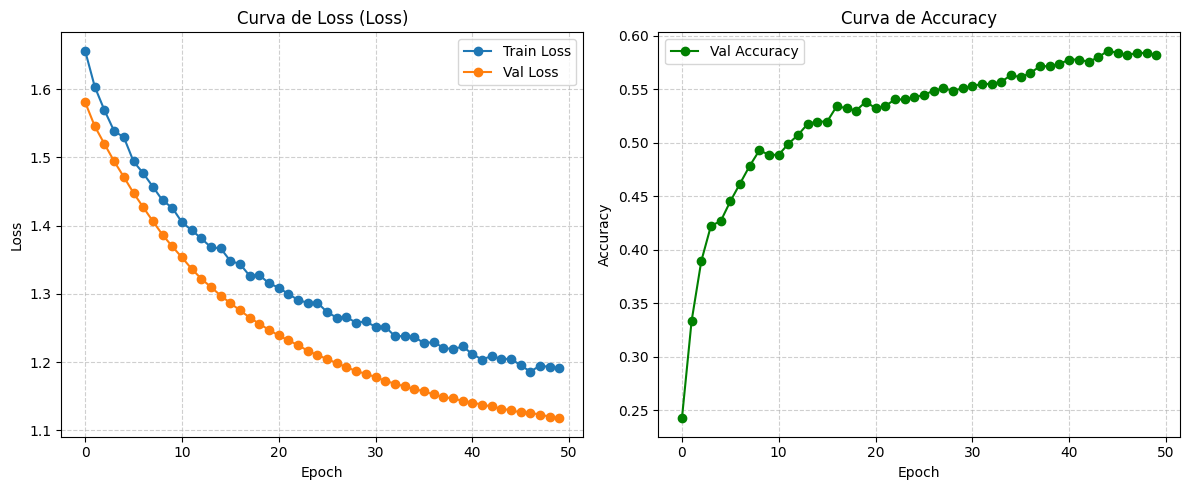

=== Val Classification Report ===
              precision    recall  f1-score   support

 Application       0.54      0.64      0.58       102
  Background       0.62      0.63      0.62        89
  Comparison       0.70      0.49      0.58       108
         Gap       0.61      0.56      0.58        91
 Improvement       0.50      0.60      0.55        93

    accuracy                           0.58       483
   macro avg       0.59      0.58      0.58       483
weighted avg       0.59      0.58      0.58       483



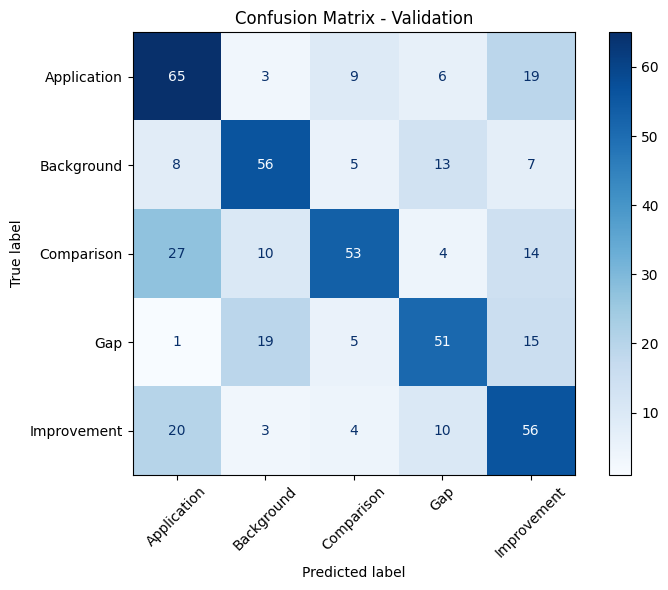

🏃 View run scibert_feature_extraction at: http://98.80.92.131:8080/#/experiments/2/runs/f15be0770b8b466fa404facf9adf7466
🧪 View experiment at: http://98.80.92.131:8080/#/experiments/2


MlflowException: If `serialization_format` is set to 'pt2', then input_example is required. It must be a numpy array or torch tensor, or a tuple/list of numpy arrays or torch tensors. This is because 'pt2' is a traced-graph format: PyTorch traces the model graph by virtually executing model.forward with the provided example input.

In [22]:
mlflow.set_experiment(config.mlflow.experiment_name)

with mlflow.start_run(run_name=RUN_NAME) as run:

    # 1. Registrar params
    mlflow.log_params(config.model.model_dump())
    mlflow.log_params(config.training.model_dump())
    mlflow.log_param("patience", patience)

    # 2. Tags
    mlflow.set_tags({
        "project": "IntenCite",
        "stage": "feature_extraction",
        "model_family": "neural_networks",
        "dataset": "multicite_3ctx_proyecto",
        "mlflow.source.name": "04_fine_tuned_scibert.ipynb"
    })

    # 3. Training
    print("Starting training...")
    model, history = train_model_mlflow(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=config.training.epochs, # Early stopping detendra si no mejora
        patience=patience,
    )

    # Artefactos en directorio temporal
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)

        # 1. Curvas de aprendizaje (plot)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
        axes[0].plot(history['val_loss'],   label='Val Loss',   marker='o')
        axes[0].set_title('Curva de Loss (Loss)')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', color='green')
        axes[1].set_title('Curva de Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        curves_path = tmp / "learning_curves.png"
        fig.savefig(curves_path, dpi=160, bbox_inches="tight")

        display(fig)
        plt.close(fig)

        mlflow.log_artifact(str(curves_path), artifact_path="evaluation")

        # 2. Classification report — Validacion
        y_true_val, y_pred_val = predict(model, val_loader, device)
        val_report_dict = classification_report(
            y_true_val, y_pred_val, target_names=target_names, output_dict=True
        )
        val_report_str = classification_report(
            y_true_val, y_pred_val, target_names=target_names
        )
        print("=== Val Classification Report ===")
        print(val_report_str)

        # 3. Matriz de Confusion — Validacion
        cm = confusion_matrix(y_true_val, y_pred_val)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
        fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
        disp.plot(cmap=plt.cm.Blues, ax=ax_cm, xticks_rotation=45)
        ax_cm.set_title("Confusion Matrix - Validation")
        plt.tight_layout()

        cm_path = tmp / "confusion_matrix_val.png"
        fig_cm.savefig(cm_path, dpi=160, bbox_inches="tight")

        display(fig_cm)
        plt.close(fig_cm)

        mlflow.log_artifact(str(cm_path), artifact_path="evaluation")

        val_report_path = tmp / "classification_report_validation.json"
        val_report_path.write_text(json.dumps(val_report_dict, indent=2), encoding="utf-8")
        mlflow.log_artifact(str(val_report_path), artifact_path="evaluation")

        # Métricas escalares de val para comparar en la tabla de runs
        mlflow.log_metric("val_accuracy", val_report_dict["accuracy"])
        mlflow.log_metric("val_precision_macro", val_report_dict["macro avg"]["precision"])
        mlflow.log_metric("val_recall_macro", val_report_dict["macro avg"]["recall"])
        mlflow.log_metric("val_f1_macro", val_report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("val_f1_micro", val_report_dict["accuracy"])


        # 3. Modelo óptimo guardado en MLflow (no en disco local)
        # mlflow.pytorch.log_model(model, name="best_scibert_fe_model")

    # Informacion del run (fuera del tempdir, sigue dentro del context manager)
    RUN_ID = run.info.run_id
    print(f"\nMLflow run ID   : {RUN_ID}")
    print(f"Experiment      : {config.mlflow.experiment_name}")
    print(f"Run             : {RUN_NAME}")

In [23]:
# Reanudamos usando la variable de la celda anterior
RUN_ID = "f15be0770b8b466fa404facf9adf7466"
with mlflow.start_run(run_id=RUN_ID):
    print(f"Guardando modelo en el run {RUN_ID} ...")

    model = model.cpu()
    model.eval()

    batch_ejemplo = next(iter(val_loader))
    input_ids = batch_ejemplo["input_ids"][0:1].cpu()
    attention_mask = batch_ejemplo["attention_mask"][0:1].cpu()

    schema_list = [
        TensorSpec(np.dtype(np.int64), (-1, -1), name="input_ids"),
        TensorSpec(np.dtype(np.int64), (-1, -1), name="attention_mask"),
    ]

    if "token_type_ids" in batch_ejemplo:
        token_type_ids = batch_ejemplo["token_type_ids"][0:1].cpu()
        input_example = (input_ids, attention_mask, token_type_ids)
        schema_list.append(TensorSpec(np.dtype(np.int64), (-1, -1), name="token_type_ids"))
    else:
        input_example = (input_ids, attention_mask)

    signature = ModelSignature(inputs=Schema(schema_list))

    mlflow.pytorch.log_model(
        model,
        artifact_path="best_scibert_fe_model",
        signature=signature,
        input_example=input_example
    )
    print("Modelo guardado exitosamente en formato pt2")


Guardando modelo en el run f15be0770b8b466fa404facf9adf7466 ...


2026/09/06 06:28:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
W0906 06:28:12.906000 46179 torch/_export/non_strict_utils.py:825] dimension inputs[0].shape[0] 0/1 specialized; Dim.AUTO was specified along with a sample input with hint = 1.
W0906 06:28:12.909000 46179 torch/_export/non_strict_utils.py:825] dimension inputs[1].shape[0] 0/1 specialized; Dim.AUTO was specified along with a sample input with hint = 1.
W0906 06:28:12.923000 46179 torch/_export/non_strict_utils.py:825] dimension inputs[2].shape[0] 0/1 specialized; Dim.AUTO was specified along with a sample input with hint = 1.
/usr/local/lib/python3.13/dist-packages/torch/export/pt2_archive/_package.py:415: UserWarning: No complete tensor found in the group! Returning the first one. This may cause issues when your weights are not on CPU.
  complete_tensor = get_complete_tensor(group, weights_dict)
2026/09/06 06:28:31 WARNING mlflow.utils.environment: Encountered an unexpected error 

Modelo guardado exitosamente en formato pt2
🏃 View run scibert_feature_extraction at: http://98.80.92.131:8080/#/experiments/2/runs/f15be0770b8b466fa404facf9adf7466
🧪 View experiment at: http://98.80.92.131:8080/#/experiments/2


In [ ]:
# Evaluacion en Test set — FUERA del context manager
print("\n=== Test Set Evaluation ===")
y_true_test, y_pred_test = predict(model, test_loader, device)
test_report = classification_report(y_true_test, y_pred_test, target_names=target_names)
print(test_report)

In [ ]:
from google.colab import files
import shutil

# Guardar los pesos matemáticos del modelo
model_path = "best_scibert_fe_weights.pth"
torch.save(model.state_dict(), model_path)
print(f"Pesos del modelo guardados en: {model_path}")

# Guardar el Tokenizador
# Reemplaza 'tokenizer' con el nombre de tu variable si se llama diferente
tokenizer_path = "./tokenizer_local"
tokenizer.save_pretrained(tokenizer_path)
print(f"Tokenizador guardado en: {tokenizer_path}")

# Comprimir el tokenizador en un zip para descargarlo fácil
shutil.make_archive("tokenizer_local", 'zip', tokenizer_path)

print("⏳ Iniciando descarga de archivos...")
try:
    files.download(model_path)
    files.download("tokenizer_local.zip")
except Exception as e:
    print("Descarga falló. Se recomienda descargarlos manualmente")
